In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chnanshika2510","key":"ee0347f348e5247a940ef6edd56af51b"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle datasets download -d arnavr10880/concrete-crack-images-for-classification


Dataset URL: https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification
License(s): Attribution 4.0 International (CC BY 4.0)
 55% 129M/233M [00:00<00:00, 1.35GB/s]
100% 233M/233M [00:00<00:00, 812MB/s] 


In [4]:
!unzip concrete-crack-images-for-classification.zip -d dataset


Streaming output truncated to the last 5000 lines.
  inflating: dataset/Positive/15001_1.jpg  
  inflating: dataset/Positive/15002_1.jpg  
  inflating: dataset/Positive/15003_1.jpg  
  inflating: dataset/Positive/15004_1.jpg  
  inflating: dataset/Positive/15005_1.jpg  
  inflating: dataset/Positive/15006_1.jpg  
  inflating: dataset/Positive/15007_1.jpg  
  inflating: dataset/Positive/15008_1.jpg  
  inflating: dataset/Positive/15009_1.jpg  
  inflating: dataset/Positive/15010_1.jpg  
  inflating: dataset/Positive/15011_1.jpg  
  inflating: dataset/Positive/15012_1.jpg  
  inflating: dataset/Positive/15013_1.jpg  
  inflating: dataset/Positive/15014_1.jpg  
  inflating: dataset/Positive/15015_1.jpg  
  inflating: dataset/Positive/15016_1.jpg  
  inflating: dataset/Positive/15017_1.jpg  
  inflating: dataset/Positive/15018_1.jpg  
  inflating: dataset/Positive/15019_1.jpg  
  inflating: dataset/Positive/15020_1.jpg  
  inflating: dataset/Positive/15021_1.jpg  
  inflating: dataset/Posi

In [5]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [6]:
import os
os.listdir('dataset')


['Positive', 'Negative']

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    'dataset',
    target_size=(img_size, img_size),
    batch_size=batch,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    'dataset',
    target_size=(img_size, img_size),
    batch_size=batch,
    class_mode='binary',
    subset='validation'
)

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


In [8]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.optimizers import Adam

def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    for layer in base.layers: layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    return Model(base.input, Dense(1, activation='sigmoid')(x))

def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    for layer in base.layers: layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    return Model(base.input, Dense(1, activation='sigmoid')(x))


In [10]:
models = {'CNN': build_cnn(), 'VGG16': build_vgg16(), 'ResNet50': build_resnet()}
histories = {}

for name, model in models.items():
    print(f"\n🔧 Training {name} model...\n")
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(train_data, validation_data=val_data, epochs=5)
    histories[name] = history
    model.save(f"{name.lower()}_crack_model.keras")



🔧 Training CNN model...

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 57ms/step - accuracy: 0.5015 - loss: 0.6984 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.4918 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.4915 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.4970 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931

🔧 Training VGG16 model...

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 255s 252ms/step - accuracy: 0.7749 - loss: 0.5169 - val_accuracy: 0.9714 - val_loss: 0.1341
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 213s 213ms/step - accuracy: 0.9648 - loss: 0.1336 - val_accuracy: 0.9902 - val_loss: 0.0553
Epoch 3/5
1000/1000 ━━━━━

In [11]:
print("Final Validation Accuracies:")
for name, model in models.items():
    _, acc = model.evaluate(val_data, verbose=0)
    print(f"{name} Accuracy: {acc*100:.2f}%")


Final Validation Accuracies:
CNN Accuracy: 50.00%
VGG16 Accuracy: 99.55%
ResNet50 Accuracy: 92.93%


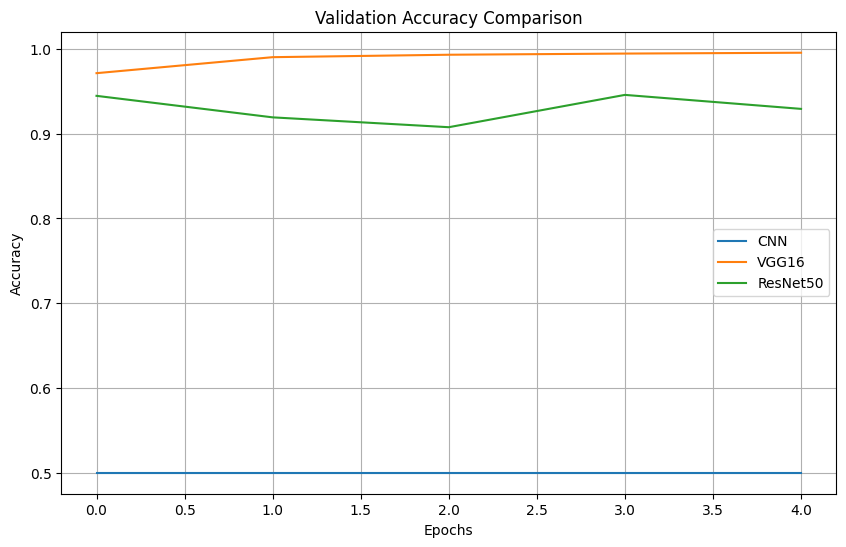

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'{name}')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [13]:
model.save('vgg16_crack_model.keras')


In [14]:
from google.colab import files
files.download('vgg16_crack_model.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Base VGG16 model (without top layer)
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom head
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

vgg16_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
vgg16_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# (Train the model here if needed...)
# vgg16_model.fit(...)

# Save properly
vgg16_model.save("vgg16_crack_model.keras")  # ✅ Better than .h5


In [16]:
from tensorflow.keras.models import load_model

model = load_model("vgg16_crack_model.keras", compile=False)
model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [17]:
from google.colab import files
files.download("vgg16_crack_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
vgg16_model.save("vgg16_crack_model.keras", include_optimizer=False)


In [19]:
from google.colab import files
files.download("vgg16_crack_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>